# Prediction with a pre-trained model (PyTorch)

## ✅ Environment / Kernel (Run this first)
- **Kernel to select in VS Code:** `Python 3.13.10 (.venv/bin/python)`
- **Activate in terminal:**
  ```bash
  cd /home/roderickperez/DataScienceProjects/faultSeg
  source .venv/bin/activate
  ```

In [1]:
import sys
import importlib

print("Python executable:", sys.executable)

for module_name in ["tensorflow", "keras", "torch"]:
    try:
        module = importlib.import_module(module_name)
        print(f"{module_name}: {module.__version__}")
    except Exception as error:
        print(f"{module_name}: not available ({error})")

try:
    import tensorflow as tf
    print("TF GPUs:", tf.config.list_physical_devices("GPU"))
except Exception as error:
    print("TF GPU check failed:", error)

try:
    import torch
    print("Torch CUDA:", torch.cuda.is_available(), "devices:", torch.cuda.device_count())
except Exception as error:
    print("Torch CUDA check failed:", error)

Python executable: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/.venv/bin/python
tensorflow: not available (No module named 'tensorflow')
keras: not available (No module named 'keras')
torch: 2.10.0+cu128
TF GPU check failed: No module named 'tensorflow'
Torch CUDA: True devices: 1


This notebook demonstrates how to use a pre-trained 3D U-Net model to perform fault segmentation on new seismic data. It covers two scenarios:
1.  **Simple Prediction:** Running inference on a single data cube (e.g., from the validation set) to quickly check model performance.
2.  **Complex Prediction:** Running inference on a large field data volume that is bigger than the model's input size. This requires a tiling (or patching) approach with overlapping and blending to produce a smooth, final result.

## Step 1: Import Libraries and Configure Environment

First, we import the necessary libraries and configure the GPU. This setup is identical to our training notebook to ensure consistency.

In [2]:
import json
import os, sys, glob
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from unet3_pytorch import unet

Check for GPU availability and configure it

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

Device: NVIDIA RTX A5000


## Step 2: Define Paths and Parameters

Here we define the paths to our data and the trained model. **Make sure `MODEL_NAME` points to the specific model file you want to use for prediction.**

In [4]:
try:                                   # for .py scripts
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:                      # for Jupyter notebooks
    ROOT_DIR = os.getcwd()

In [5]:
# Step 2: Define Paths and Parameters
# --- Data Paths ---
BASE_DIR = ROOT_DIR

ORIG_DATA_DIR = os.path.join(BASE_DIR, "data")
VAL_DIR       = os.path.join(ORIG_DATA_DIR, "validation_npy")
MODEL_DIR     = os.path.join(BASE_DIR, "model")

OSV_SGY_PATH = os.environ.get("OSV_SGY_PATH")
OSV_FAULTSEG_OUTPUT_DIR = os.environ.get("OSV_FAULTSEG_OUTPUT_DIR")
OSV_TARGET_INLINE = os.environ.get("OSV_TARGET_INLINE")
RUN_OSV_BATCH = bool(OSV_SGY_PATH and OSV_FAULTSEG_OUTPUT_DIR)
print("OSV batch mode:", RUN_OSV_BATCH)

# --- Model Paths ---------------------------------------------------
# Automatically pick the newest .pth checkpoint
pth_ckpts = sorted(
    [f for f in os.listdir(MODEL_DIR) if f.endswith(".pth")],
    key=lambda x: os.path.getmtime(os.path.join(MODEL_DIR, x))
)
if not pth_ckpts:
    raise FileNotFoundError(f"No .pth checkpoints found in {MODEL_DIR}")

MODEL_NAME = pth_ckpts[-1]
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)
print("Will load model:", MODEL_NAME)

# Optional large-volume demo path (used only when RUN_OSV_BATCH is False)
F3D_DIR = os.path.join(ROOT_DIR, "..", "data", "data_from_Wu", "prediction", "f3d")
F3D_DIR = os.path.abspath(F3D_DIR)

if RUN_OSV_BATCH:
    print("Batch mode: large-volume demo file check disabled.")
else:
    if not os.path.exists(os.path.join(F3D_DIR, "gxl.dat")):
        # Fallback to internal data structure if external path is missing
        fallback_dir = os.path.join(BASE_DIR, "data", "data_from_Wu", "fp", "f3d")
        if os.path.exists(os.path.join(fallback_dir, "gxl.dat")):
            F3D_DIR = fallback_dir

# --- Model Input Parameters ---------------------------------------
PATCH_N1 = PATCH_N2 = PATCH_N3 = 128
OVERLAP = 12

OSV batch mode: False
Will load model: unet_pytorch_model_200pairs_25epochs_2026-03-14_01-57-12.pth


## Step 3: Load the Trained Model

We load the compiled model from the specified file.

In [6]:
# Step 3: Load the Trained PyTorch model
if RUN_OSV_BATCH:
    print("Skipping demo model load in batch mode; predict_sgy_inline.py will load the model directly.")
    model = None
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

    print("Loading model:", MODEL_PATH)
    model = unet(input_size=(PATCH_N1, PATCH_N2, PATCH_N3), pretrained_weights=None)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    print("Model loaded & eval mode set.")

Device: NVIDIA RTX A5000
Loading model: /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/faultSeg_2019_pyTorch/model/unet_pytorch_model_200pairs_25epochs_2026-03-14_01-57-12.pth
Model loaded & eval mode set.


In [7]:
if RUN_OSV_BATCH:
    from predict_sgy_inline import run_prediction

    batch_result = run_prediction(
        sgy_path=Path(OSV_SGY_PATH),
        output_dir=Path(OSV_FAULTSEG_OUTPUT_DIR),
        model_path=Path(MODEL_PATH),
        target_inline=int(OSV_TARGET_INLINE) if OSV_TARGET_INLINE else None,
    )
    print(json.dumps(batch_result, indent=2))
else:
    batch_result = None
    print("Notebook demo mode enabled.")

Notebook demo mode enabled.


## Step 4: Simple Prediction on a Validation Sample

This is a sanity check to ensure the model loads and predicts correctly. We take one sample from the validation set, apply the same preprocessing as in training, and visualize the result.

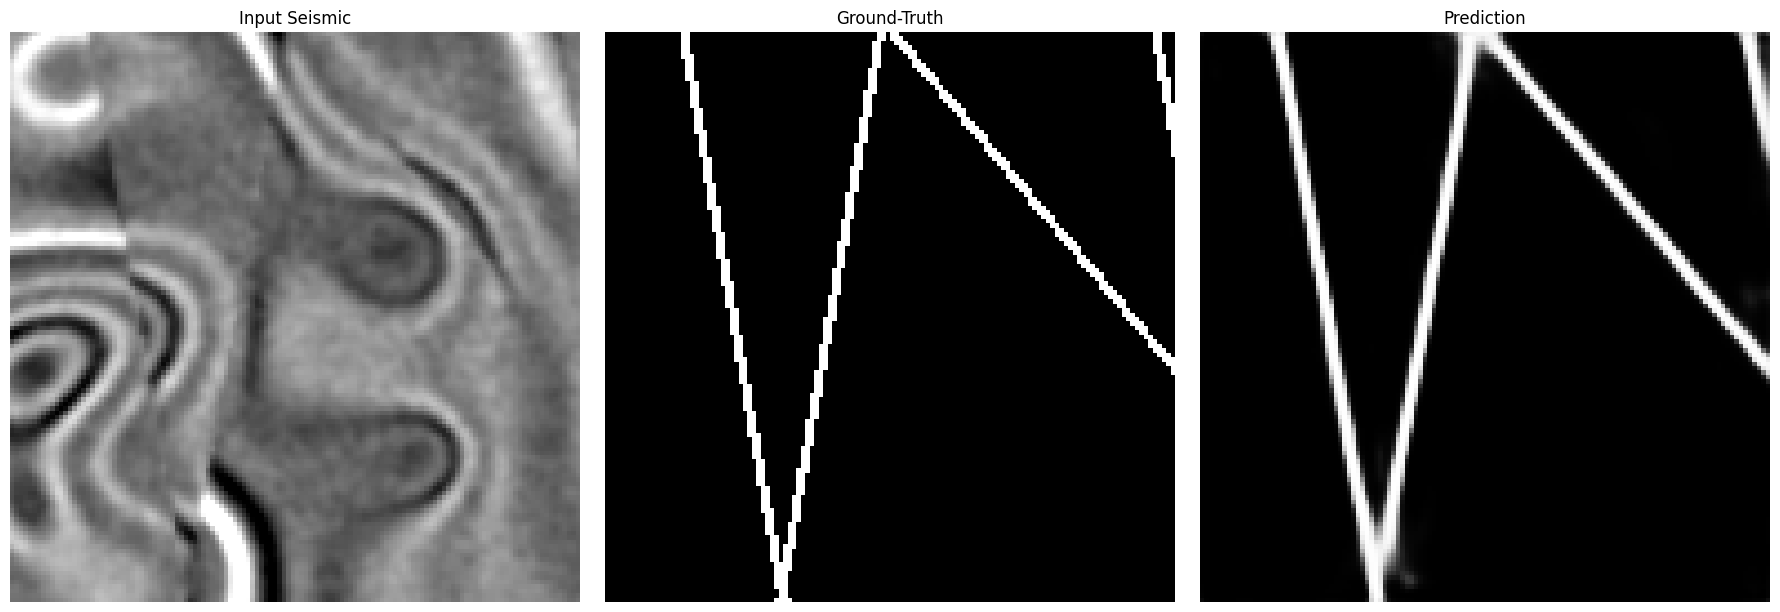

Saved combined image to /home/roderickperez/DataScienceProjects/OptimalSurfaceVoting_OSV/faultSeg_2019_pyTorch/output/images/prediction_slice_64.png


In [8]:
# Step 4: Simple Prediction on a Validation Sample
# This is a sanity check to ensure the model loads and predicts correctly.

if RUN_OSV_BATCH:
    print("Skipping validation demo in batch mode.")
else:
    SAMPLE_ID = "10"
    gx = np.load(os.path.join(VAL_DIR, "seis",  f"{SAMPLE_ID}.npy"))
    fx = np.load(os.path.join(VAL_DIR, "fault", f"{SAMPLE_ID}.npy"))

    gx_norm = (gx - gx.mean()) / (gx.std() + 1e-8)
    gx_tr   = np.transpose(gx_norm)
    fx_tr   = np.transpose(fx)

    input_tensor = torch.from_numpy(gx_tr).unsqueeze(0).unsqueeze(0).to(device, dtype=torch.float)
    with torch.no_grad():
        fp_tensor = model(input_tensor)
    fp_tr = fp_tensor.squeeze().cpu().numpy()

    SLICE = 64

    output_dir = os.path.join(BASE_DIR, "output", "images")
    os.makedirs(output_dir, exist_ok=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].set_title("Input Seismic")
    axes[0].imshow(gx_tr[SLICE].T, cmap='gray', vmin=-2, vmax=2)
    axes[0].axis('off')

    axes[1].set_title("Ground-Truth")
    axes[1].imshow(fx_tr[SLICE].T, cmap='gray', vmin=0, vmax=1)
    axes[1].axis('off')

    axes[2].set_title("Prediction")
    axes[2].imshow(fp_tr[SLICE].T, cmap='gray', vmin=0, vmax=1)
    axes[2].axis('off')

    plt.tight_layout()
    save_path = os.path.join(output_dir, f"prediction_slice_{SLICE}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved combined image to {save_path}")

## Step 5: Complex Prediction on a Large Field Image (Tiling/Patching)

Real-world seismic volumes are much larger than the model's `128x128x128` input size. To handle this, we use a patch-based approach:
1.  **Padding:** The large volume is padded with zeros to ensure it's perfectly divisible by our patch-and-stride logic.
2.  **Tiling:** We slide a `128x128x128` window across the padded volume with a defined overlap.
3.  **Blending:** To avoid sharp edges in the final prediction, we use a Gaussian mask. Predictions in the center of a patch have a higher weight than those at the edges.
4.  **Stitching:** We accumulate the weighted predictions and the weights themselves. The final fault probability at each point is the sum of weighted predictions divided by the sum of weights.

In [9]:
# Step 5: Complex Prediction on a Large Field Image (Tiling/Patching)

def create_gaussian_mask(overlap, shape1, shape2, shape3):
    # Create 1D Gaussian window (actually linear ramp as per Keras notebook)
    def get_window(size, overlap):
        w = np.ones(size)
        w[:overlap] = np.linspace(0, 1, overlap)
        w[-overlap:] = np.linspace(1, 0, overlap)
        return w

    # Create 3D mask
    w1 = get_window(shape1, overlap)
    w2 = get_window(shape2, overlap)
    w3 = get_window(shape3, overlap)
    
    mask = np.einsum('i,j,k->ijk', w1, w2, w3)
    return mask


In [10]:
if RUN_OSV_BATCH:
    print("Skipping full-volume demo in batch mode.")
else:
    f3d_path = os.path.join(F3D_DIR, 'gxl.dat')
    if not os.path.exists(f3d_path):
        pass
    else:
        m3, m2, m1 = 512, 384, 128
        gx = np.fromfile(f3d_path, dtype=np.single).reshape(m3, m2, m1)
        print(f"Loaded F3 field data with shape: {gx.shape}")

        gx = np.transpose(gx)
        m1, m2, m3 = gx.shape
        print(f"Transposed shape for processing: {gx.shape}")

        overlap_size = OVERLAP
        stride = (PATCH_N1 - overlap_size, PATCH_N2 - overlap_size, PATCH_N3 - overlap_size)

        p1 = (stride[0] - (m1 - PATCH_N1) % stride[0]) % stride[0]
        p2 = (stride[1] - (m2 - PATCH_N2) % stride[1]) % stride[1]
        p3 = (stride[2] - (m3 - PATCH_N3) % stride[2]) % stride[2]
        gp = np.pad(gx, ((0,p1), (0,p2), (0,p3)), mode='constant', constant_values=0)
        padded_shape = gp.shape
        print(f"Padded shape: {padded_shape}")

        gy = np.zeros(padded_shape, dtype=np.single)
        mk = np.zeros(padded_shape, dtype=np.single)
        sc = create_gaussian_mask(overlap_size, PATCH_N1, PATCH_N2, PATCH_N3)

        k1_range = range(0, padded_shape[0] - PATCH_N1 + 1, stride[0])
        k2_range = range(0, padded_shape[1] - PATCH_N2 + 1, stride[1])
        k3_range = range(0, padded_shape[2] - PATCH_N3 + 1, stride[2])

        print("Starting tiling prediction on large volume...")
        for k1 in tqdm(k1_range, desc="Dim 1"):
            for k2 in k2_range:
                for k3 in k3_range:
                    patch = gp[k1:k1+PATCH_N1, k2:k2+PATCH_N2, k3:k3+PATCH_N3]
                    patch_processed = (patch - np.mean(patch)) / (np.std(patch) + 1e-8)

                    input_patch = torch.from_numpy(patch_processed).unsqueeze(0).unsqueeze(0).to(device, dtype=torch.float)
                    with torch.no_grad():
                        predicted_patch_tensor = model(input_patch)

                    predicted_patch = predicted_patch_tensor.squeeze().cpu().numpy()
                    gy[k1:k1+PATCH_N1, k2:k2+PATCH_N2, k3:k3+PATCH_N3] += predicted_patch * sc
                    mk[k1:k1+PATCH_N1, k2:k2+PATCH_N2, k3:k3+PATCH_N3] += sc

        gy = np.divide(gy, mk, out=np.zeros_like(gy), where=mk!=0)
        fp_final = gy[:m1, :m2, :m3]

        print(f"Prediction complete. Final fault probability map shape: {fp_final.shape}")

        output_filename = os.path.join(F3D_DIR, "fp_pytorch.dat")
        fp_final.astype(np.single).tofile(output_filename)

        print(f"Final prediction saved to: {output_filename}")